<a href="https://colab.research.google.com/github/ristaangdembay/Bootcamp-DA-AI/blob/main/Capstone_Project_1_Customer_Churn_Prediction(Rista_Angdembay).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project 1: Customer Churn Prediction for T-Mobile

## Problem Statement
T-Mobile, like many companies in the telecommunications industry, faces critical challenge: customer churn. Predicting which customers are most likely to churn can allow T-Mobile to implement proactive measures to retain them, thereby increasing customer lifetime value (CLV) and overall profitability.
The goal of this project is to develop a predictive model to estimate the likelihood of customer churn based on various customer and transactional data. By accurately predicting which customers are at risk, T-Mobile can develop targeted retention strategies, improve customer satisfaction, and optimize marketing efforts.
This model will empower T-Mobile to reduce churn rates and maximize customer retention in an increasingly competitive industry.



## I. Team Requirement
To complete this project successfully, a diverse team is required to handle various aspects of data analysis, machine learning, and business insights. Below is a breakdown of roles and responsibilities:
Team Roles and Responsibilities
1.	Project Manager (1 person)

    Responsibilities:
 - Oversee the project timeline, and deliverables, and ensure the team is on track.
 - Communicate with stakeholders (e.g., T-Mobile) for requirements and feedback.
    
    Skills Required:
 - Strong communication, project management, experience in data science projects, stakeholder management.

2.	Data Engineer (1-2 people)

    Responsibilities:
 - Handle data extraction from the company's databases (e.g., SQL queries).
 - Manage data pipelines and preprocessing (cleaning, handling missing values, outliers).
 - Create scalable ETL (Extract, Transform, Load) pipelines for large datasets.

	Skills Required:SQL, Python (Pandas, NumPy), ETL tools (e.g., Apache Airflow, Alteryx), cloud platforms (AWS, GCP), database management.

3.	Data Analyst (1-2 people)

	Responsibilities:
 - Perform Exploratory Data Analysis (EDA) to uncover key insights.
 - Create visualizations and reports to highlight trends, correlations, and patterns.
 - Provide feature engineering and selection recommendations based on EDA.

    Skills Required: Python (Pandas, NumPy), data visualization tools (Matplotlib, Seaborn, Tableau), statistical analysis, strong analytical skills.

4.	Machine Learning Engineer (2 people)
    Responsibilities:
  - Build and train machine learning models to predict customer churn.
  - Evaluate models using appropriate metrics and optimize performance.
  - Collaborate with data engineers to ensure a smooth data flow from ETL to modeling.

    Skills Required: Python (scikit-learn, XGBoost), machine learning algorithms, hyperparameter tuning, model evaluation (accuracy, precision, recall, F1-Score), familiarity with cloud services for deployment.

5.	Dashboard Developer / Business Intelligence Specialist (1 person)
    Responsibilities:
   - Create an interactive dashboard to visualize churn metrics.
   -	Ensure the dashboard is intuitive for stakeholders to explore data and predictions.
   - Integrate insights from the machine learning model and enable dynamic filtering.

    Skills Required: Power BI, Tableau, Plotly (if using Python), data visualization, strong UI/UX design for dashboarding.
6.	Business Analyst (1 person)

    Responsibilities:
    - Translate business needs into technical requirements.
    - Provide actionable business insights based on the model’s predictions.
    - Help the team focus on relevant KPIs (Key Performance Indicators) related to customer churn.

    Skills Required: Domain expertise in business, strong communication, ability to bridge the gap between data and actionable business strategies, experience with churn metrics.

## II. Skills Requirement
The project demands a range of technical and business skills across the team:
1.	Programming Languages:
    - Python: For data preprocessing, EDA, and machine learning model development.
    - SQL: For querying data from the company's database.
2.	Data Analysis and Visualization:
    - Pandas and NumPy for data manipulation.
    - Matplotlib, Seaborn, Power BI, or Tableau for data visualization.
    - Plotly for creating interactive charts in Python.
3.	Machine Learning:
    - Familiarity with scikit-learn, XGBoost, or TensorFlow for building and training models.
    - Experience with hyperparameter tuning (e.g., using GridSearchCV).
    - Understanding of model evaluation metrics such as accuracy, precision, recall, F1-Score, ROC-AUC.
4.	Database Management:
    - Proficiency in SQL for extracting and querying data.
    -	Experience with data pipelines and handling large datasets.
5.	Dashboarding & Reporting:
    - Ability to build interactive dashboards with Power BI or Tableau.
    - Skills in connecting dashboards to live data sources and enabling user interaction through filtering and dynamic views.
6.	Business Insights:
    - Strong business acumen to understand and extract actionable insights related to customer churn.


## Perform the customer churn prediction following the steps below


# Step 1. Data Collection


In [6]:
# install sqlachemy for acquiring databases and data preprocessing
pip install sqlalchemy

In [11]:
# Import libraries
from sqlalchemy import create_engine
import pandas as pd

# Load the CSV data
# Downloaded the datasets from the Kaggle and it is attached on the reprosiotry as well
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Create SQLite engine
engine = create_engine('sqlite:///telco_customer_churn.db')

#Load dataframe into a new SQL table called churn_data
df.to_sql('churn_data', con = engine, if_exists = 'replace', index = False)

# Now the data us in the SQLite database, you can query it using SQL.
query = "SELECT * FROM churn_data LIMIT 5"
df_sql = pd.read_sql(query, con = engine)

# Display the queried data
print(df_sql)



   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

#Step 2. Data Preprocessing:
create a databases excluding the null value

In [14]:
# Query thr SQLite database
# Extracting the datasets with only necessary featues and target value with no null value using SQL commnad
query = """
SELECT customerID, tenure, MonthlyCharges, TotalCharges, Churn FROM churn_data
WHERE TotalCharges IS NOT NULL;
"""

# Fetch the data from SQLite database into pandas DataFrame
df_sql = pd.read_sql(query, con = engine)

# Display the first few rows
print(df_sql.head())

   customerID  tenure  MonthlyCharges TotalCharges Churn
0  7590-VHVEG       1           29.85        29.85    No
1  5575-GNVDE      34           56.95       1889.5    No
2  3668-QPYBK       2           53.85       108.15   Yes
3  7795-CFOCW      45           42.30      1840.75    No
4  9237-HQITU       2           70.70       151.65   Yes


In [15]:
# Encode 'Churn as 1 for 'Yes' and 0 for 'No'
df_sql['Churn'] = df_sql['Churn'].apply(lambda x:1 if x == 'Yes' else 0)
df_sql.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,29.85,29.85,0
1,5575-GNVDE,34,56.95,1889.5,0
2,3668-QPYBK,2,53.85,108.15,1
3,7795-CFOCW,45,42.30,1840.75,0
4,9237-HQITU,2,70.70,151.65,1


In [16]:
# Print the information of the database like datatypes and no.of null
df_sql.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      7043 non-null   object 
 1   tenure          7043 non-null   int64  
 2   MonthlyCharges  7043 non-null   float64
 3   TotalCharges    7043 non-null   object 
 4   Churn           7043 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 275.2+ KB


In [23]:
# Verifying the null value
df_sql.isna().sum()

,0
customerID,0
tenure,0
MonthlyCharges,0
TotalCharges,0
Churn,0


In [26]:
# Converting the 'TotalCharges' datatypes from object to float for he efficiency of implimanting statistical modeling in the next step
df_sql['TotalCharges'] = pd.to_numeric(df_sql['TotalCharges'], errors = 'coerce')
df_sql.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      7043 non-null   object 
 1   tenure          7043 non-null   int64  
 2   MonthlyCharges  7043 non-null   float64
 3   TotalCharges    7032 non-null   float64
 4   Churn           7043 non-null   int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 275.2+ KB


#3.Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

# Scaling the 'MonthlyChrges' and 'TotalCharges' columns
scaler = StandardScaler()
df_sql[['MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(df_sql[['MonthlyCharges', 'TotalCharges']])


### Split the data into train and test set

In [28]:
from sklearn.model_selection import train_test_split

# Feature and Target
x = df_sql [['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df_sql['Churn']

# Splitting the data into training(80%) and testing(20%) data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)


# Step 4. Build and Evaluate Machine Learning Models
We will use a RandomForestClassifier Model  from a sklearn library to fit our  datasets and make some prediction based on the model.

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Train the RandomForestClassifier
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(x_train, y_train)

# Make prediction on the test set
y_pred = model.predict(x_test)


# Step 5. Model Evaluation

#### Calculate the precision, recall and accuracy score of the model

In [34]:
# Evaluate the Model
from sklearn.metrics import precision_score, recall_score, accuracy_score

# calculate the precision
precision = precision_score(y_test, y_pred)

# Calcualte recall
recall = recall_score(y_test, y_pred)

# Calcualte the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print the results
print(f"Precision: {precision}")
print(f"Recall : {recall}")
print(f"Model accuracy : {accuracy:.22f}")

Precision: 0.5888501742160279
Recall : 0.45308310991957107
Model accuracy : 0.7714691270404542278172


#### Confusion Matrix:
 Plot the confusion matrix to visul;ize the number of true positives, true negatives, false positives and false negatives after making predictions

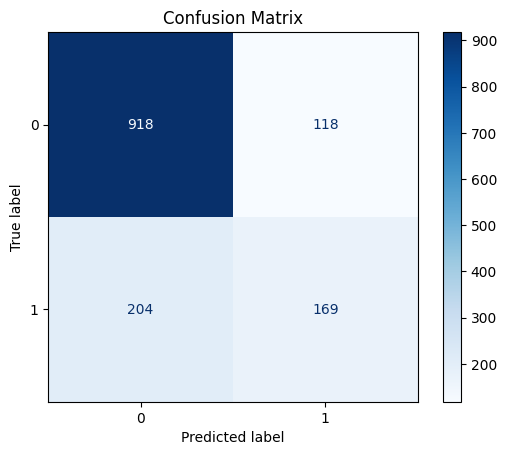

In [31]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Blues')
plt.title('Confusion Matrix')
plt.show()

# Step 6: Summaray and Conclusion
### 1. Model Performance:

  - The model's accuracy of 77.7% is
decent but could be misleading if the dataset is imbalanced (more non-churners than churners). In cases of imbalance, Recall and Precision are more important metrics than overall accuracy.
  - Precision is 59%, meaning that more than half of the customers predicted to churn actually churned, which is good but could be improved.
  - Recall is 45%, which indicates that the model misses a large portion of the actual churners (55%). Improving recall should be a priority if the goal is to retain as many churn-prone customers as possible.

### 2.Business Implications:

   - False Negatives (Missed Churners): The model is missing many churners (45% Recall), which means you may fail to take action on customers who are likely to leave. Improving Recall will help target more at-risk customers.
   - False Positives (Unnecessary Retention): While the false positive rate is reasonable (11.4%), reducing unnecessary retention efforts could optimize costs.



While the accuracy is acceptable, the Recall (45%) and F1-Score (0.51) indicate that the model is not capturing enough churners, and there’s room for improvement, especially if the business goal is to maximize customer retention.